In [ ]:
import pandas as pd

df = pd.read_csv('applequality.csv')

display(df.head())

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590,good
1,1,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809,good
2,2,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636,bad
3,3,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723,good
4,4,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984,good


In [ ]:
display(df.isnull().sum())

,0
A_id,0
Size,0
Weight,0
Sweetness,0
Crunchiness,0
Juiciness,0
Ripeness,0
Acidity,0
Quality,0


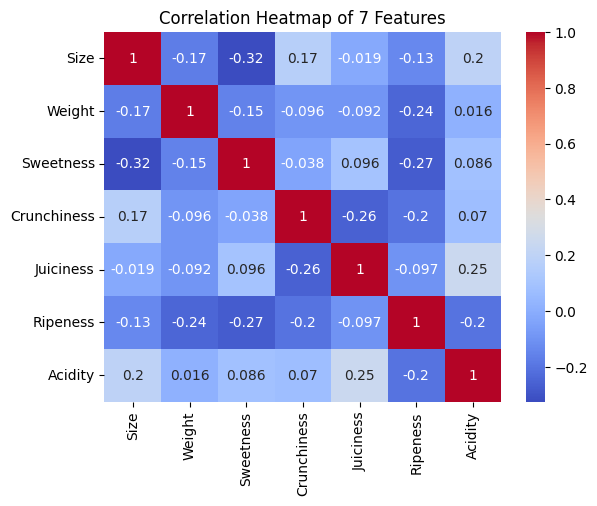

In [ ]:
selected_features0 = ['Size', 'Weight', 'Sweetness', 'Crunchiness', 'Juiciness','Ripeness','Acidity']

# Create new DataFrame with just these 5
df_selected= df[selected_features0]


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_selected.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of 7 Features')
plt.show()

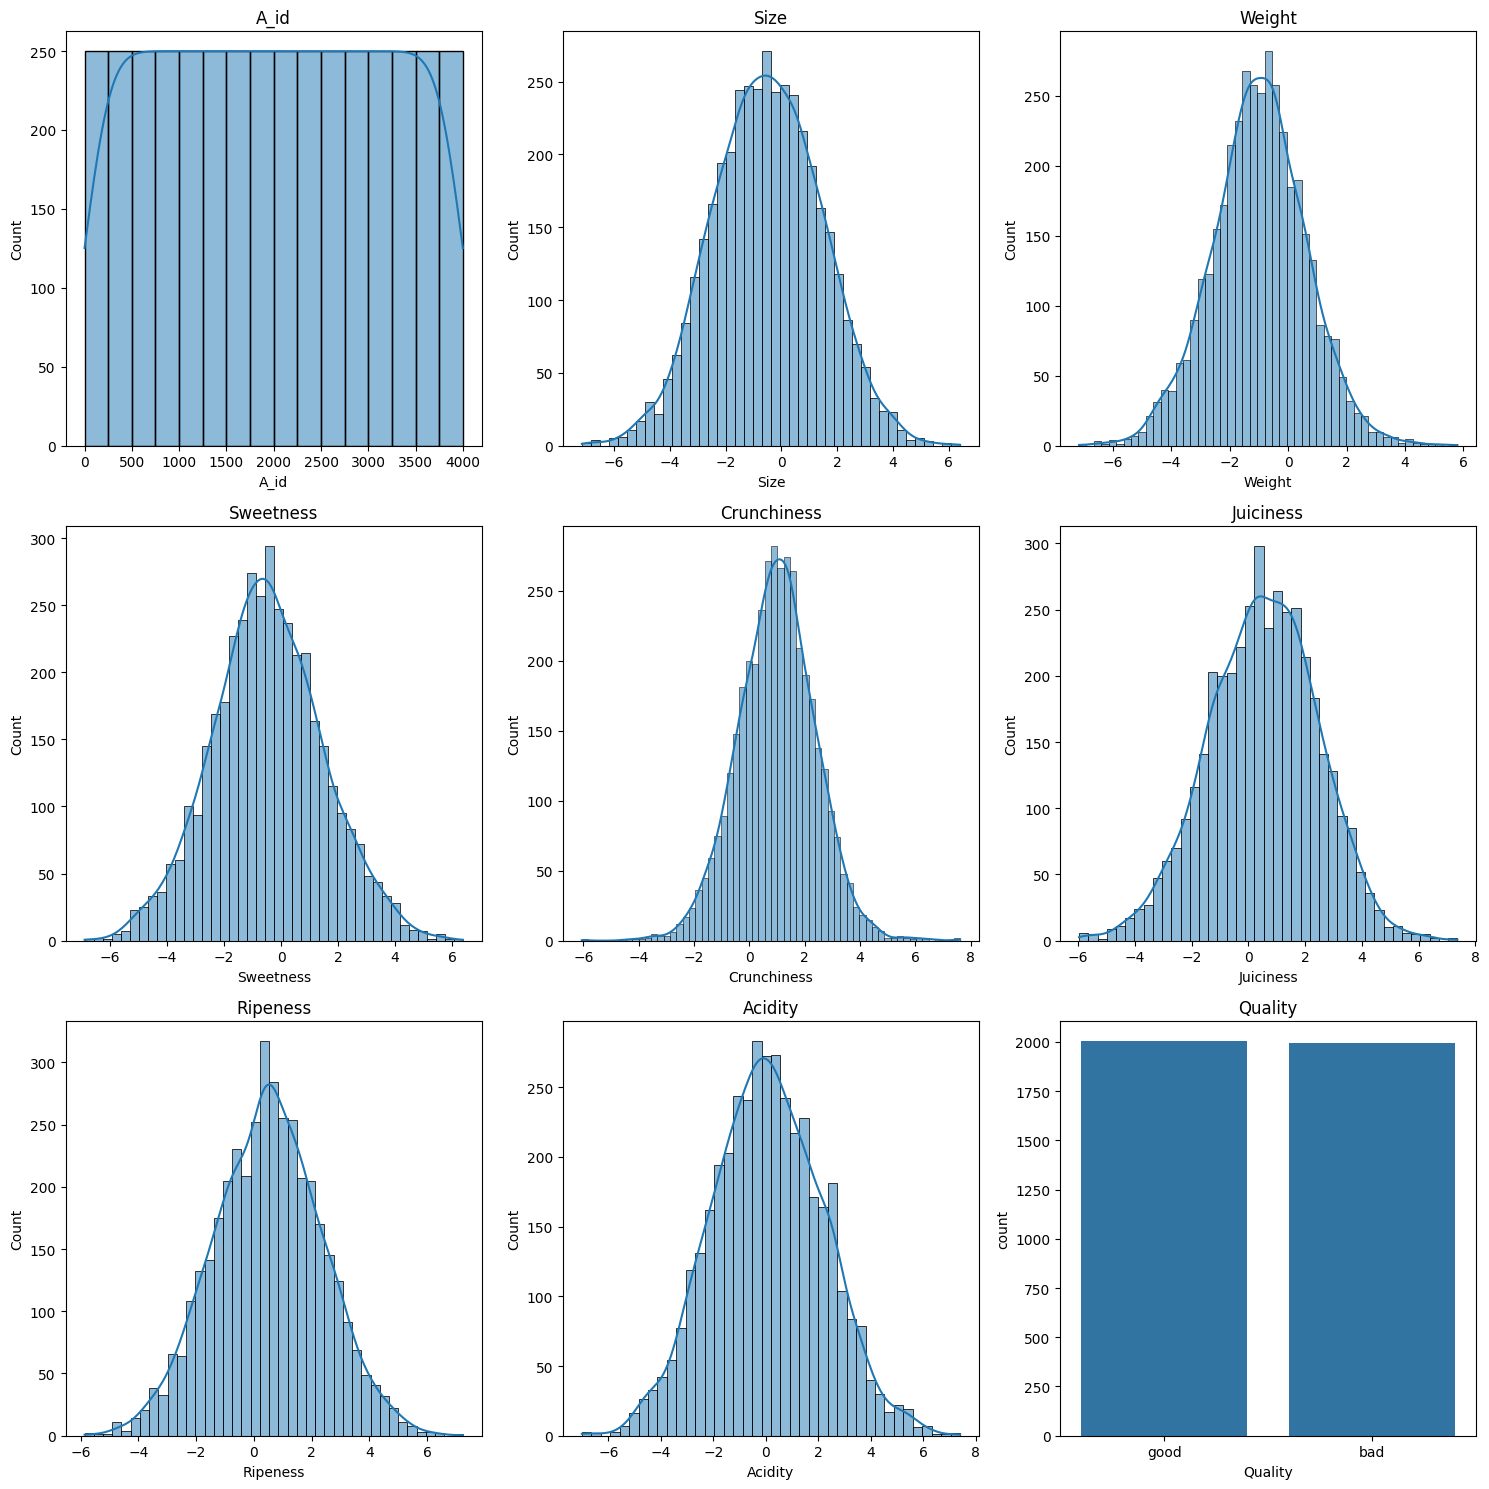

In [ ]:


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have a DataFrame named 'df'

# Calculate the number of rows and columns for the subplot grid
num_features = len(df.columns)
num_cols = 3  # You can adjust this based on your preference
num_rows = (num_features + num_cols - 1) // num_cols

# Create a subplot grid
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))

# Iterate through the features and plot their distributions
for i, feature in enumerate(df.columns):
  row = i // num_cols
  col = i % num_cols
  ax = axes[row, col]

  # Plot a histogram for numerical features
  if pd.api.types.is_numeric_dtype(df[feature]):
    sns.histplot(df[feature], kde=True, ax=ax)
  # Plot a bar plot for categorical features
  else:
    sns.countplot(x=feature, data=df, ax=ax)

  ax.set_title(feature)

# Remove any unused subplots
for i in range(num_features, num_rows * num_cols):
  row = i // num_cols
  col = i % num_cols
  fig.delaxes(axes[row, col])

plt.tight_layout()
plt.show()


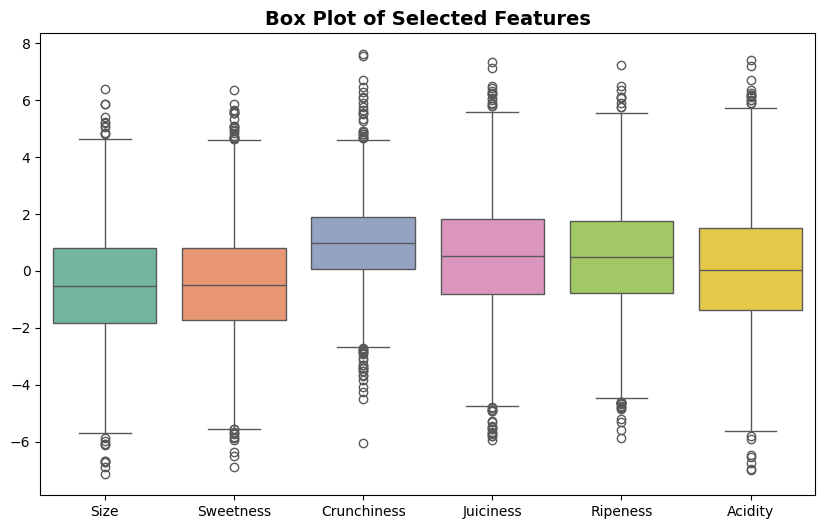

In [ ]:
import seaborn as sns

selected_features1 = ['Size', 'Sweetness', 'Crunchiness','Juiciness','Ripeness','Acidity']  # replace with your column names

plt.figure(figsize=(10, 6))
sns.boxplot(data=df[selected_features1], palette='Set2')
plt.title('Box Plot of Selected Features', fontsize=14, fontweight='bold')
plt.show()

In [ ]:
def remove_outliers_iqr(df, features):
    for feature in features:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[feature] >= lower_bound) & (df[feature] <= upper_bound)]
    return df

selected_features2 = ['Size', 'Sweetness', 'Crunchiness','Juiciness','Ripeness','Acidity']  # replace with your feature names
df_cleaned = remove_outliers_iqr(df, selected_features2)

df=df_cleaned


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

features= ['Size', 'Weight', 'Sweetness', 'Crunchiness', 'Juiciness','Ripeness','Acidity']
target = ['Quality']

X = df[features]
y = df[target]


# Then map
y = df[target].replace({'good': 1, 'bad': 0})


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


<ipython-input-8-00d63b885726>:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = df[target].replace({'good': 1, 'bad': 0})


In [ ]:
model = SVC(kernel='rbf')  # You can also try 'rbf', 'poly', etc.
model.fit(X_train, y_train)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC()

Accuracy: 0.89
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.89      0.90       405
           1       0.88      0.90      0.89       362

    accuracy                           0.89       767
   macro avg       0.89      0.89      0.89       767
weighted avg       0.89      0.89      0.89       767



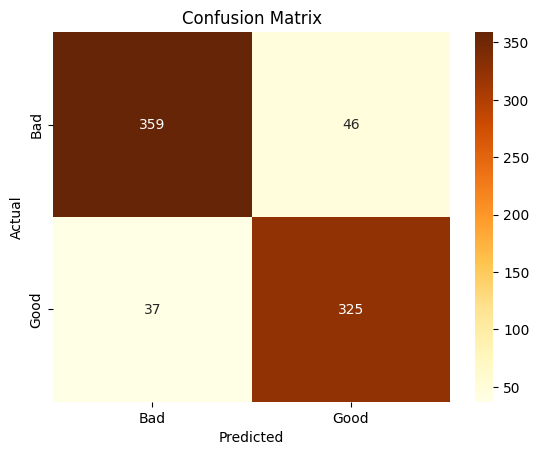

In [ ]:
# Predict on X_test
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

from sklearn.metrics import classification_report

print("Classification Report:\n", classification_report(y_test, y_pred))

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr', xticklabels=['Bad', 'Good'], yticklabels=['Bad', 'Good'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.81      0.81       405
           1       0.79      0.79      0.79       362

    accuracy                           0.80       767
   macro avg       0.80      0.80      0.80       767
weighted avg       0.80      0.80      0.80       767

Accuracy: 0.80


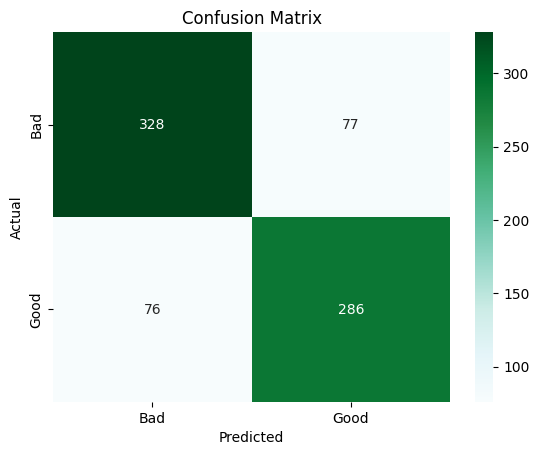

In [ ]:
# Predict on X_test
y_pred = dt_model.predict(X_test)

from sklearn.metrics import classification_report

print("Classification Report:\n", classification_report(y_test, y_pred))

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Calculate and plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='BuGn',
            xticklabels=['Bad', 'Good'], yticklabels=['Bad', 'Good'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()